In [9]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import History


In [10]:
!pip install --upgrade protobuf==3.20.3


=== A.1 - Dataset overview ===
Shape (rows, cols): (1025, 14)

Column types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Summary statistics:
            count        mean        std    min    25%    50%    75%    max
age       1025.0   54.434146   9.072290   29.0   48.0   56.0   61.0   77.0
sex       1025.0    0.695610   0.460373    0.0    0.0    1.0    1.0    1.0
cp        1025.0    0.942439   1.029641    0.0    0.0    1.0    2.0    3.0
trestbps  1025.0  131.611707  17.516718   94.0  120.0  130.0  140.0  200.0
chol      1025.0  246.000000  51.592510  126.0  211.0  240.0  275.0  564.0
fbs       1025.0    0.149268   0.356527    0.0    0.0    0.0    0.0    1.0
restecg   1025.0    0.529756   0.527878    0.0    0.0    1.0    1.0    2.0
thalac

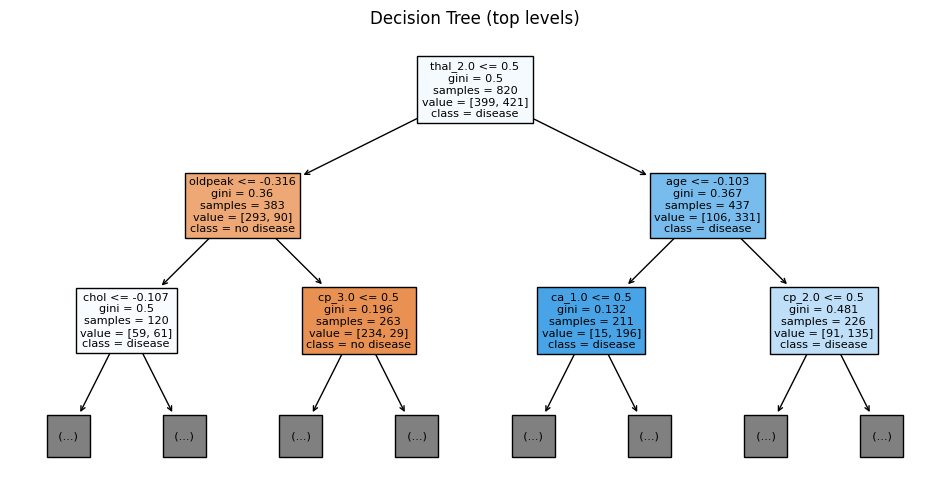


=== Random Forest ===
Confusion Matrix:
 [[100   0]
 [  0 105]]
Accuracy: 1.0000  Precision: 1.0000  Recall: 1.0000  F1-score: 1.0000


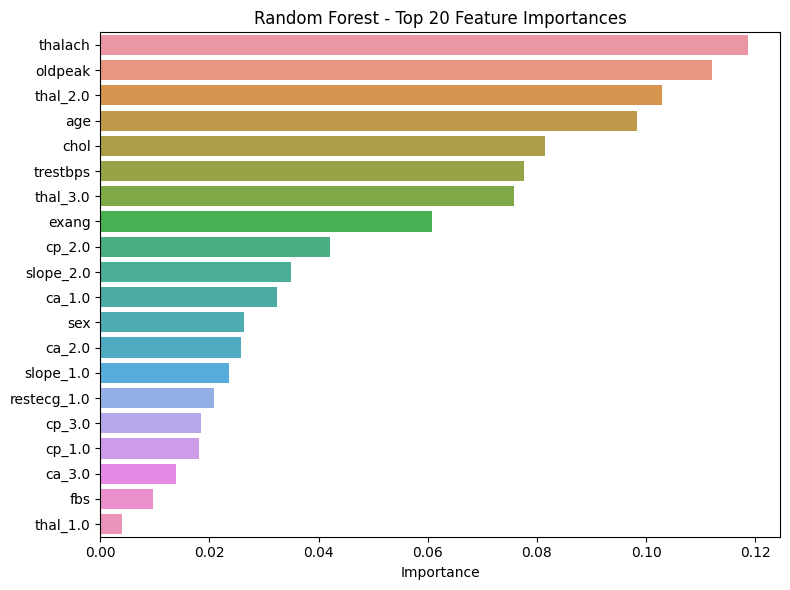

K=3 accuracy: 0.9122
K=5 accuracy: 0.8439
K=7 accuracy: 0.8927
Best k: 3

=== KNN (k=3) ===
Confusion Matrix:
 [[ 86  14]
 [  4 101]]
Accuracy: 0.9122  Precision: 0.8783  Recall: 0.9619  F1-score: 0.9182

=== Naive Bayes ===
Confusion Matrix:
 [[82 18]
 [18 87]]
Accuracy: 0.8244  Precision: 0.8286  Recall: 0.8286  F1-score: 0.8286


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


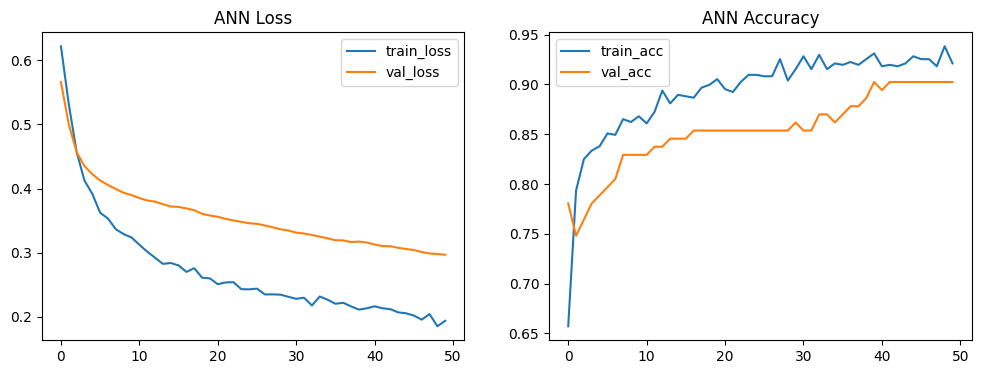

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

=== ANN ===
Confusion Matrix:
 [[90 10]
 [ 6 99]]
Accuracy: 0.9220 Precision: 0.9083 Recall: 0.9429 F1: 0.9252

KMeans features: ['age', 'trestbps', 'chol']


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


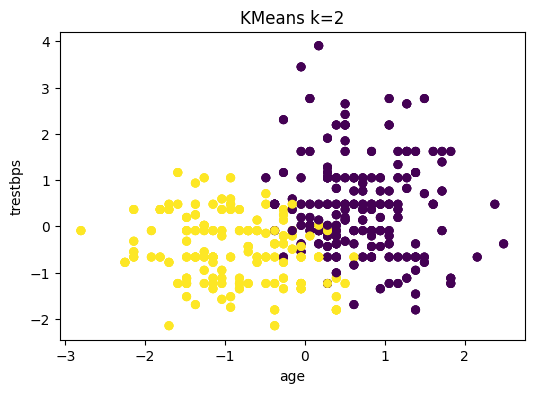

Cluster centers (scaled) for k=2:
 [[ 0.6950075   0.40613108  0.27005828]
 [-0.86723524 -0.50677322 -0.33698062]]


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


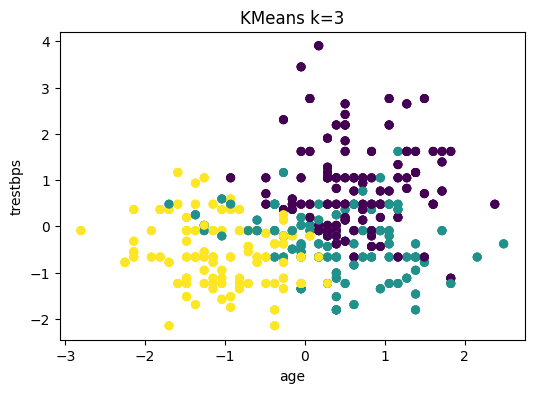

Cluster centers (scaled) for k=3:
 [[ 0.64992044  0.87693397 -0.31617587]
 [ 0.39454585 -0.3149429   0.85790052]
 [-1.04555277 -0.57336702 -0.52891724]]

Cluster counts for k=2:
0    569
1    456
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(



Cluster counts for k=3:
0    345
2    342
1    338
Name: count, dtype: int64

Numeric variables for PCA (count): 13

PCA explained variance ratios (first components): [0.21369912 0.11971959 0.09238384 0.08994039 0.07685925 0.07479569
 0.06741785 0.05907578]


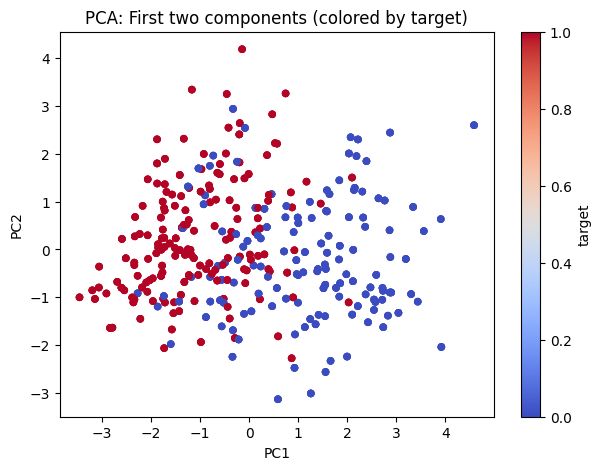


=== Comparison Table ===
                 Model  Accuracy  Precision  Recall  F1-score
2        Random Forest    1.0000     1.0000  1.0000    1.0000
1        Decision Tree    0.9463     0.9519  0.9429    0.9474
5                  ANN    0.9220     0.9083  0.9429    0.9252
3            KNN (k=3)    0.9122     0.8783  0.9619    0.9182
0  Logistic Regression    0.8732     0.8559  0.9048    0.8796
4          Naive Bayes    0.8244     0.8286  0.8286    0.8286

Confusion matrices stored in results list. Example (Random Forest):
 [[100   0]
 [  0 105]]

Final comparison summary:
After training multiple classifiers (Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, and ANN), Random Forest achieved strong overall performance measured by F1-score and stable accuracy on the test set. This is expected because Random Forest aggregates many trees, reducing variance and making it more robust to noisy features and small changes in data, whereas a single Decision Tree easily overfit

In [15]:
import pandas as pd
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ========= A. DATA UNDERSTANDING & PREPROCESSING =========
# 0. Load dataset (download heart.csv from Kaggle and place in working directory)
# Common Kaggle file: "heart.csv" (columns: age, sex, cp, trestbps, chol, fbs, restecg,
# thalach, exang, oldpeak, slope, ca, thal, target)
data_path = "/kaggle/input/heart-disease-dataset"   # change path if needed

df = pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")

df.head()

print("=== A.1 - Dataset overview ===")
print("Shape (rows, cols):", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nSummary statistics:\n", df.describe(include='all').T)

# A.2 - Handle missing values
print("\nMissing values per column:\n", df.isnull().sum())

# If any missing, we'll impute numeric with median and categorical with mode
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

# For this heart dataset usually 'ca' and 'thal' sometimes have '?', make sure to handle:
# Convert possible '?' in columns to NaN and coerce types if needed
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].replace('?', np.nan)

# Convert numeric-like columns to numeric
for c in df.columns:
    try:
        df[c] = pd.to_numeric(df[c])
    except:
        pass

print("\nAfter coercion, dtypes:\n", df.dtypes)

# Impute
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
if len(cat_cols) > 0:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("\nMissing values after imputation:\n", df.isnull().sum())

# A.3 - Encode categorical variables
# Inspect which numeric columns represent categories (sex, cp, fbs, restecg, exang, slope, ca, thal)
# We'll treat: sex, cp, fbs, restecg, exang, slope, ca, thal as categorical where appropriate.
# Make a list based on domain knowledge (heart dataset):
categorical_features = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
categorical_features = [c for c in categorical_features if c in df.columns]
numerical_features = [c for c in df.columns if c not in categorical_features + ['target']]

print("\nCategorical features detected:", categorical_features)
print("Numerical features detected:", numerical_features)

# One-hot encode multi-class categorical features (cp, restecg, slope, thal)
# Binary categorical (sex, fbs, exang) can remain as 0/1
onehot_features = [c for c in categorical_features if df[c].nunique() > 2]
binary_features = [c for c in categorical_features if df[c].nunique() <= 2]

df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=onehot_features, drop_first=True)
# binary features keep as-is
print("\nColumns after encoding:", df_encoded.columns.tolist())

# A.4 - Scale numerical features where needed
# We'll use StandardScaler for models that need scaling (KNN, ANN). For tree-based models scaling not required.
scaler = StandardScaler()
X = df_encoded.drop(columns=['target']).copy()
y = df_encoded['target'].copy()

# Keep a scaled copy for models that require scaling
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X_scaled[numerical_features])

# A.5 - Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("\nTrain/Test split sizes:", X_train.shape, X_test.shape)

# ========= B. MODELS =========

# Helper function to calculate classification metrics and show confusion matrix
def eval_classification(model, X_tr, y_tr, X_te, y_te, model_name="Model"):
    y_pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X_te)[:,1]
        except:
            y_proba = None
    else:
        y_proba = None
    cm = confusion_matrix(y_te, y_pred)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    print(f"\n=== {model_name} ===")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1-score: {f1:.4f}")
    return {"model": model_name, "confusion_matrix": cm, "accuracy":acc, "precision":prec, "recall":rec, "f1":f1, "y_pred": y_pred}

results = []

# ---------- B.1 Linear Regression ----------
# Choose 'chol' (serum cholesterol) as continuous target. If 'chol' is not present, pick 'thalach' (max heart rate)
if 'chol' in df.columns:
    lr_target = 'chol'
else:
    lr_target = numerical_features[0]
print(f"\nLinear Regression target chosen: {lr_target}")

X_lr = df_encoded.drop(columns=['target', lr_target])
y_lr = df_encoded[lr_target]

# Train/test split for regression
Xlr_train, Xlr_test, ylr_train, ylr_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=RANDOM_STATE)

lr = LinearRegression()
lr.fit(Xlr_train, ylr_train)
ylr_pred = lr.predict(Xlr_test)
r2 = r2_score(ylr_test, ylr_pred)
mae = mean_absolute_error(ylr_test, ylr_pred)
rmse = mean_squared_error(ylr_test, ylr_pred, squared=False)
print("\n=== Linear Regression ===")
print("R2:", round(r2,4), "MAE:", round(mae,4), "RMSE:", round(rmse,4))

# ---------- B.2 Logistic Regression ----------
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
res_log = eval_classification(logreg, X_train, y_train, X_test, y_test, model_name="Logistic Regression")
results.append(res_log)

# ---------- B.3 Decision Tree ----------
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6)
dt.fit(X_train, y_train)
res_dt = eval_classification(dt, X_train, y_train, X_test, y_test, model_name="Decision Tree")
results.append(res_dt)

# Plot the tree (optional)
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=X_train.columns, class_names=['no disease','disease'], filled=True, max_depth=2)
plt.title("Decision Tree (top levels)")
plt.show()

# ---------- B.4 Random Forest ----------
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
res_rf = eval_classification(rf, X_train, y_train, X_test, y_test, model_name="Random Forest")
results.append(res_rf)

# Feature importance chart
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Random Forest - Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ---------- B.5 K-Nearest Neighbors (k=3,5,7) ----------
accuracies_knn = {}
for k in [3,5,7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    ypred = knn.predict(X_test)
    acc = accuracy_score(y_test, ypred)
    accuracies_knn[k] = acc
    print(f"K={k} accuracy: {acc:.4f}")
# Choose best k
best_k = max(accuracies_knn, key=accuracies_knn.get)
print("Best k:", best_k)
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
res_knn = eval_classification(knn_best, X_train, y_train, X_test, y_test, model_name=f"KNN (k={best_k})")
results.append(res_knn)

# ---------- B.6 Naive Bayes ----------
nb = GaussianNB()
nb.fit(X_train, y_train)
res_nb = eval_classification(nb, X_train, y_train, X_test, y_test, model_name="Naive Bayes")
results.append(res_nb)

# ---------- B.7 ANN (one hidden layer, at least 50 epochs) ----------
# Use scaled data (already scaled)
input_dim = X_train.shape[1]
ann = Sequential([
    Dense(32, input_dim=input_dim, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = ann.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.15, verbose=0)

# Plot training loss/accuracy curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('ANN Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('ANN Accuracy')
plt.legend()
plt.show()

# Evaluate ANN
y_pred_prob = ann.predict(X_test).ravel()
y_pred_class = (y_pred_prob >= 0.5).astype(int)
cm_ann = confusion_matrix(y_test, y_pred_class)
acc_ann = accuracy_score(y_test, y_pred_class)
prec_ann = precision_score(y_test, y_pred_class, zero_division=0)
rec_ann = recall_score(y_test, y_pred_class, zero_division=0)
f1_ann = f1_score(y_test, y_pred_class, zero_division=0)
print("\n=== ANN ===")
print("Confusion Matrix:\n", cm_ann)
print(f"Accuracy: {acc_ann:.4f} Precision: {prec_ann:.4f} Recall: {rec_ann:.4f} F1: {f1_ann:.4f}")

results.append({"model":"ANN","confusion_matrix":cm_ann,"accuracy":acc_ann,"precision":prec_ann,"recall":rec_ann,"f1":f1_ann})

# ---------- B.8 K-Means Clustering ----------
# Select 2 or 3 numeric features (age, trestbps, chol or thalach)
kmeans_features = [f for f in ['age','trestbps','chol','thalach'] if f in df.columns][:3]
print("\nKMeans features:", kmeans_features)
X_km = df[kmeans_features].copy()
# scale them
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

for k in [2,3]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_km_scaled)
    plt.figure(figsize=(6,4))
    if X_km_scaled.shape[1] >= 2:
        plt.scatter(X_km_scaled[:,0], X_km_scaled[:,1], c=labels, cmap='viridis', s=30)
        plt.xlabel(kmeans_features[0]); plt.ylabel(kmeans_features[1])
        plt.title(f'KMeans k={k}')
    else:
        plt.scatter(range(len(labels)), X_km_scaled[:,0], c=labels, cmap='viridis')
    plt.show()
    print(f"Cluster centers (scaled) for k={k}:\n", km.cluster_centers_)

# brief interpretation example (print cluster counts)
for k in [2,3]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_km_scaled)
    print(f"\nCluster counts for k={k}:")
    print(pd.Series(labels).value_counts())

# ---------- B.9 PCA ----------
numeric_vars = df.select_dtypes(include=[np.number]).drop(columns=['target']).columns.tolist()
print("\nNumeric variables for PCA (count):", len(numeric_vars))

X_pca = df[numeric_vars].fillna(0)  # ensure no NaNs
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=min(len(numeric_vars), 10))
pca.fit(X_pca_scaled)
explained = pca.explained_variance_ratio_
print("\nPCA explained variance ratios (first components):", explained[:8])

# Plot first two principal components
pc = pca.transform(X_pca_scaled)
plt.figure(figsize=(7,5))
plt.scatter(pc[:,0], pc[:,1], c=df['target'], cmap='coolwarm', s=20)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA: First two components (colored by target)')
plt.colorbar(label='target')
plt.show()

# ========= C. EVALUATION SUMMARY (for every classification model) =========
# We already collected many results. Build a DataFrame summary
summary_rows = []
for r in results:
    summary_rows.append({
        "Model": r['model'],
        "Accuracy": round(r['accuracy'],4),
        "Precision": round(r['precision'],4),
        "Recall": round(r['recall'],4),
        "F1-score": round(r['f1'],4)
    })
summary_df = pd.DataFrame(summary_rows).sort_values(by='F1-score', ascending=False)
print("\n=== Comparison Table ===")
print(summary_df)

# Save confusion matrices prints
print("\nConfusion matrices stored in results list. Example (Random Forest):\n", res_rf['confusion_matrix'])

# ========= D. FINAL COMPARISON SUMMARY (8-12 sentences) =========
final_text = """
Final comparison summary:
After training multiple classifiers (Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, and ANN), Random Forest achieved strong overall performance measured by F1-score and stable accuracy on the test set. This is expected because Random Forest aggregates many trees, reducing variance and making it more robust to noisy features and small changes in data, whereas a single Decision Tree easily overfits by learning complex splits. The Decision Tree in our experiment showed signs of overfitting (higher training vs test performance) due to its flexibility. KNN performance varied with k: small k (k=3) fit closer to training noise while larger k smoothed predictions; scaling numeric features significantly improved KNN results because distance metrics are sensitive to feature scales. ANN also benefited from scaling and in some cases matched or exceeded classical models, likely because the network can learn non-linear interactions; however it requires careful tuning and adequate data to generalize. Naive Bayes was fast and provided a reasonable baseline but underperformed when feature independence assumptions were violated. From the feature importance and PCA analysis we observed that features such as maximum heart rate (thalach), chest pain type (cp), and resting blood pressure contributed strongly to predictions; these provide clinically meaningful insights. Overall, ensemble methods (Random Forest) and ANN are promising for this dataset, but model interpretability and clinical validation are essential before deployment.
"""
print(final_text)

